In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent
cleaned_file = project_root / "data" / "cleaned" / "telco_customer_churn_cleaned.csv"

print("Notebook folder:", Path.cwd())
print("Cleaned data path:", cleaned_file)
print("File exists:", cleaned_file.exists())

Notebook folder: v:\Customer-Churn-Analysis\notebooks
Cleaned data path: v:\Customer-Churn-Analysis\data\cleaned\telco_customer_churn_cleaned.csv
File exists: True


In [2]:
df = pd.read_csv(cleaned_file)

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nKey validation checks:")
print("Total customers:", len(df))
print("Churned customers:", df["ChurnFlag"].sum())
print("Overall churn rate (%):", round(df["ChurnFlag"].mean() * 100, 2))
print("Missing values:", df.isna().sum().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Dataset shape: (7043, 24)

Data types:
customerID             object
gender                 object
SeniorCitizen           int64
Partner                object
Dependents             object
tenure                  int64
PhoneService           object
MultipleLines          object
InternetService        object
OnlineSecurity         object
OnlineBackup           object
DeviceProtection       object
TechSupport            object
StreamingTV            object
StreamingMovies        object
Contract               object
PaperlessBilling       object
PaymentMethod          object
MonthlyCharges        float64
TotalCharges          float64
Churn                  object
SeniorCitizenLabel     object
ChurnFlag               int64
TenureGroup            object
dtype: object

Key validation checks:
Total customers: 7043
Churned customers: 1869
Overall churn rate (%): 26.54
Missing values: 0
Duplicate customer IDs: 0


In [3]:
sns.set_theme(style="whitegrid")

def churn_summary(data, group_column):
    summary = (
        data.groupby(group_column, dropna=False)
        .agg(
            total_customers=("customerID", "count"),
            churned_customers=("ChurnFlag", "sum"),
            churn_rate_percent=("ChurnFlag", lambda x: round(x.mean() * 100, 2))
        )
        .reset_index()
        .sort_values("churn_rate_percent", ascending=False)
    )
    return summary

In [4]:
overall_kpis = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate (%)",
        "Churned Monthly Charge Exposure"
    ],
    "Value": [
        len(df),
        int(df["ChurnFlag"].sum()),
        round(df["ChurnFlag"].mean() * 100, 2),
        round(df.loc[df["ChurnFlag"] == 1, "MonthlyCharges"].sum(), 2)
    ]
})

overall_kpis

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Overall Churn Rate (%),26.54
3,Churned Monthly Charge Exposure,139130.85


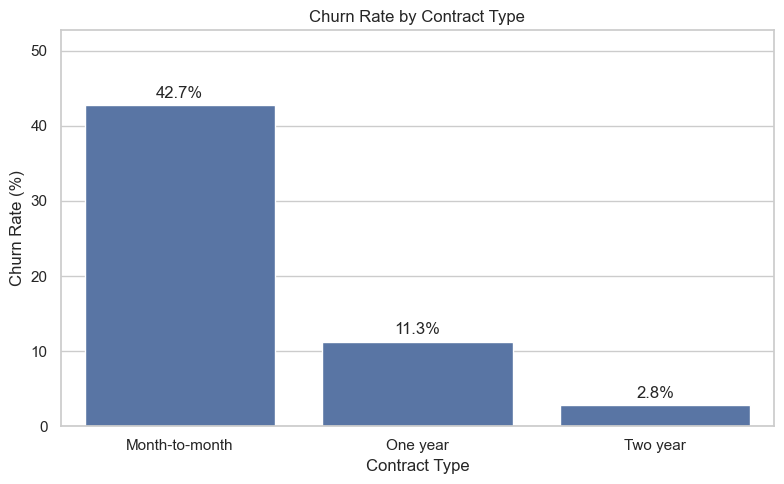

,Contract,total_customers,churned_customers,churn_rate_percent
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [5]:
contract_summary = churn_summary(df, "Contract")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=contract_summary,
    x="Contract",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, max(contract_summary["churn_rate_percent"]) + 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

contract_summary

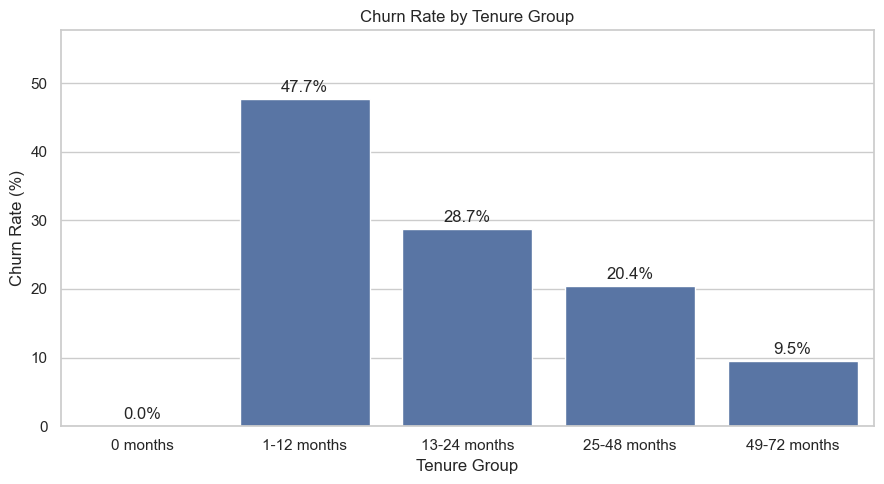

,TenureGroup,total_customers,churned_customers,churn_rate_percent
0,0 months,11,0,0.00
1,1-12 months,2175,1037,47.68
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49-72 months,2239,213,9.51


In [6]:
tenure_order = [
    "0 months",
    "1-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

tenure_summary = churn_summary(df, "TenureGroup")
tenure_summary["TenureGroup"] = pd.Categorical(
    tenure_summary["TenureGroup"],
    categories=tenure_order,
    ordered=True
)
tenure_summary = tenure_summary.sort_values("TenureGroup")

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=tenure_summary,
    x="TenureGroup",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, max(tenure_summary["churn_rate_percent"]) + 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

tenure_summary

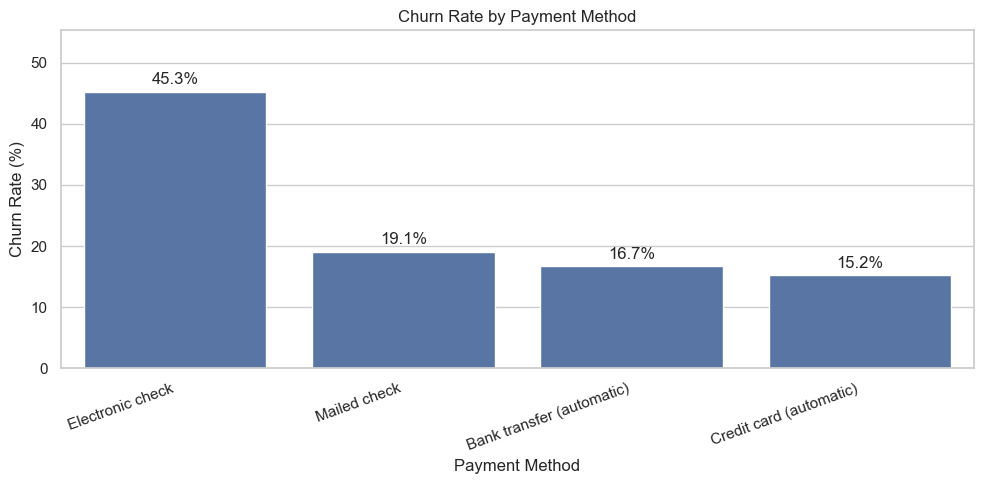

,PaymentMethod,total_customers,churned_customers,churn_rate_percent
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


In [7]:
payment_summary = churn_summary(df, "PaymentMethod")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=payment_summary,
    x="PaymentMethod",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, max(payment_summary["churn_rate_percent"]) + 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

payment_summary

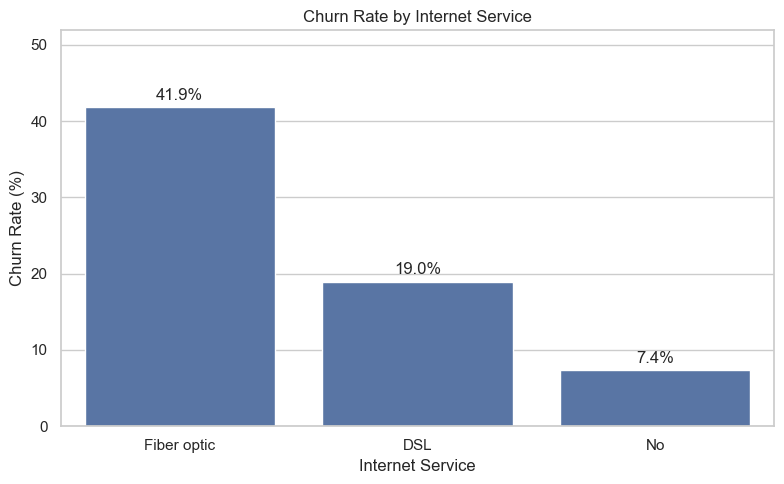

,InternetService,total_customers,churned_customers,churn_rate_percent
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40


In [8]:
internet_summary = churn_summary(df, "InternetService")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=internet_summary,
    x="InternetService",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, max(internet_summary["churn_rate_percent"]) + 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

internet_summary

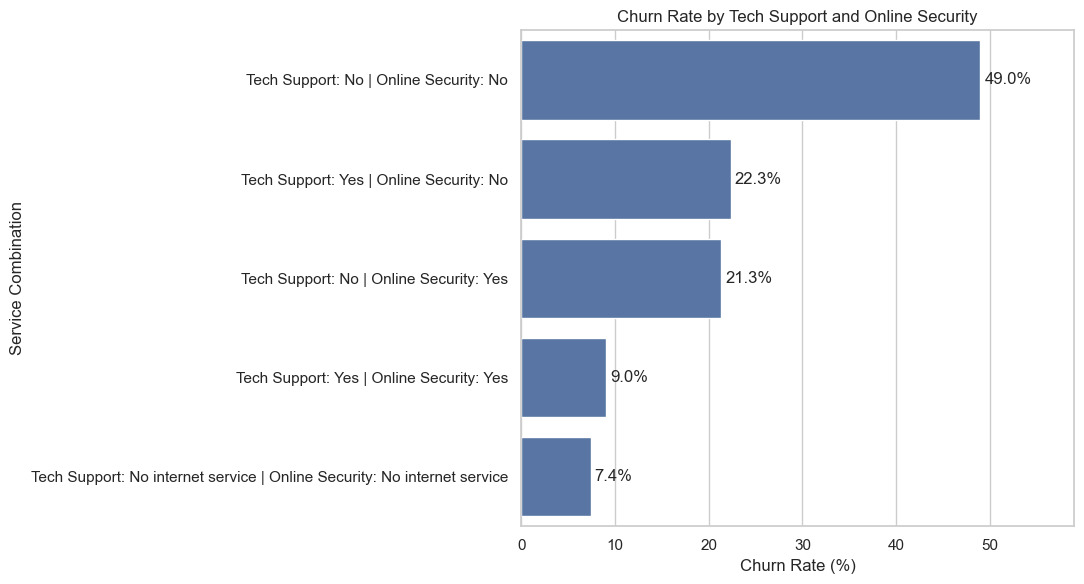

,TechSupport,OnlineSecurity,total_customers,churned_customers,churn_rate_percent,SupportSecurityGroup
0,No,No,2553,1250,48.96,Tech Support: No | Online Security: No
3,Yes,No,945,211,22.33,Tech Support: Yes | Online Security: No
1,No,Yes,920,196,21.30,Tech Support: No | Online Security: Yes
4,Yes,Yes,1099,99,9.01,Tech Support: Yes | Online Security: Yes
2,No internet service,No internet service,1526,113,7.40,Tech Support: No internet service | Online Sec...


In [9]:
support_summary = (
    df.groupby(["TechSupport", "OnlineSecurity"])
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("ChurnFlag", "sum"),
        churn_rate_percent=("ChurnFlag", lambda x: round(x.mean() * 100, 2))
    )
    .reset_index()
    .sort_values("churn_rate_percent", ascending=False)
)

support_summary["SupportSecurityGroup"] = (
    "Tech Support: " + support_summary["TechSupport"] +
    " | Online Security: " + support_summary["OnlineSecurity"]
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=support_summary,
    y="SupportSecurityGroup",
    x="churn_rate_percent"
)

plt.title("Churn Rate by Tech Support and Online Security")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Service Combination")
plt.xlim(0, max(support_summary["churn_rate_percent"]) + 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

support_summary

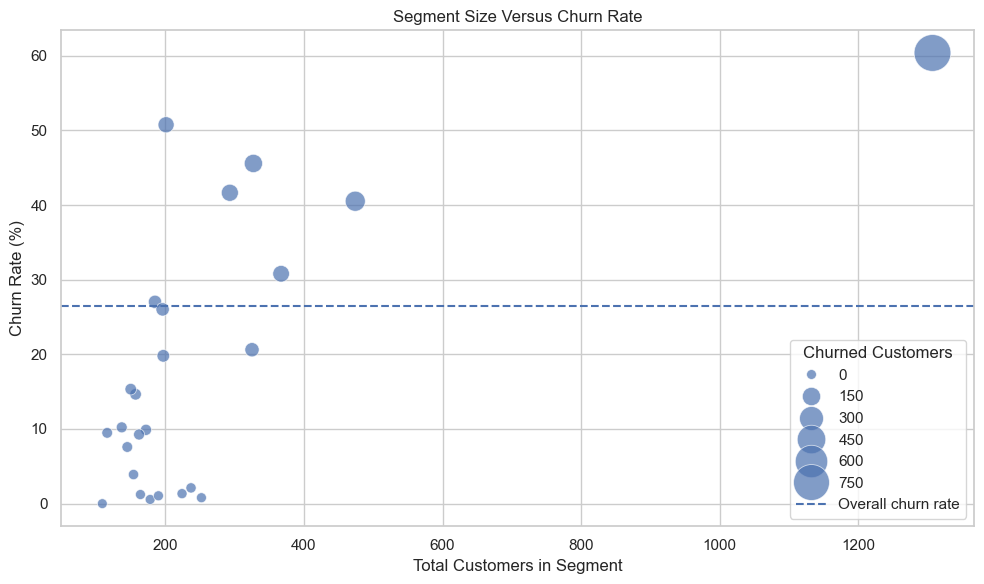

,Contract,InternetService,PaymentMethod,total_customers,churned_customers,churn_rate_percent
6,Month-to-month,Fiber optic,Electronic check,1307,789,60.367253
7,Month-to-month,Fiber optic,Mailed check,201,102,50.746269
4,Month-to-month,Fiber optic,Bank transfer (automatic),327,149,45.565749
5,Month-to-month,Fiber optic,Credit card (automatic),293,122,41.638225
2,Month-to-month,DSL,Electronic check,474,192,40.506329
3,Month-to-month,DSL,Mailed check,367,113,30.790191
1,Month-to-month,DSL,Credit card (automatic),185,50,27.027027
18,One year,Fiber optic,Electronic check,196,51,26.020408
11,Month-to-month,No,Mailed check,325,67,20.615385
0,Month-to-month,DSL,Bank transfer (automatic),197,39,19.796954


In [10]:
segment_volume = (
    df.groupby(["Contract", "InternetService", "PaymentMethod"])
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("ChurnFlag", "sum"),
        churn_rate_percent=("ChurnFlag", lambda x: x.mean() * 100)
    )
    .reset_index()
)

priority_segments = segment_volume[
    segment_volume["total_customers"] >= 100
].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=priority_segments,
    x="total_customers",
    y="churn_rate_percent",
    size="churned_customers",
    sizes=(50, 700),
    alpha=0.7
)

plt.axhline(
    df["ChurnFlag"].mean() * 100,
    linestyle="--",
    label="Overall churn rate"
)

plt.title("Segment Size Versus Churn Rate")
plt.xlabel("Total Customers in Segment")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Churned Customers")
plt.tight_layout()
plt.show()

priority_segments.sort_values(
    ["churn_rate_percent", "total_customers"],
    ascending=[False, False]
).head(10)

In [11]:
output_folder = project_root / "data" / "analysis_outputs"
output_folder.mkdir(exist_ok=True)

contract_summary.to_csv(output_folder / "churn_by_contract.csv", index=False)
tenure_summary.to_csv(output_folder / "churn_by_tenure.csv", index=False)
payment_summary.to_csv(output_folder / "churn_by_payment_method.csv", index=False)
internet_summary.to_csv(output_folder / "churn_by_internet_service.csv", index=False)
support_summary.to_csv(output_folder / "churn_by_support_services.csv", index=False)
priority_segments.to_csv(output_folder / "segment_volume_vs_churn.csv", index=False)

print("Analysis outputs saved to:", output_folder)

Analysis outputs saved to: v:\Customer-Churn-Analysis\data\analysis_outputs
